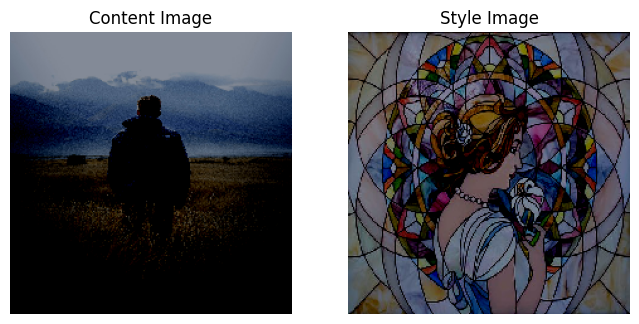

Iteration: 0 Loss: 1.5131536e+16
Iteration: 50 Loss: 1.4450628e+16
Iteration: 100 Loss: 1.3607484e+16
Iteration: 150 Loss: 1.2670262e+16
Iteration: 200 Loss: 1.172288e+16
Iteration: 250 Loss: 1.0826827e+16


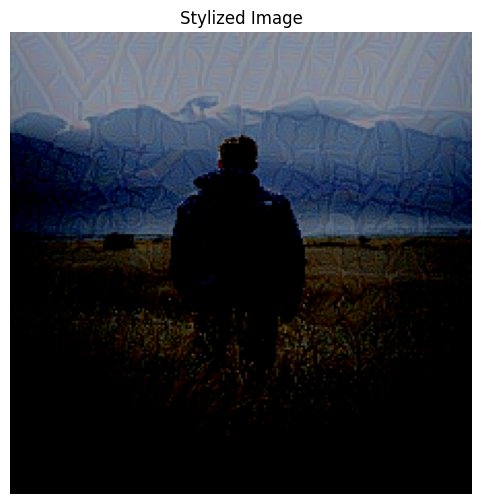

In [5]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model


# Content image
urllib.request.urlretrieve(
"https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d",
"content.jpg"
)

# Style image
urllib.request.urlretrieve(
"https://raw.githubusercontent.com/pytorch/examples/main/fast_neural_style/images/style-images/mosaic.jpg",
"style.jpg"
)



def load_img(path):

    img = image.load_img(path, target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    return img


content_image = load_img("content.jpg")
style_image = load_img("style.jpg")



def show_image(img):

    img = img.reshape((224,224,3))
    img = img[:,:,::-1]
    img = np.clip(img,0,255).astype("uint8")

    plt.imshow(img)
    plt.axis("off")

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
show_image(content_image)
plt.title("Content Image")

plt.subplot(1,2,2)
show_image(style_image)
plt.title("Style Image")

plt.show()


vgg = VGG19(weights='imagenet', include_top=False)
vgg.trainable = False



content_layer = ['block5_conv2']

style_layers = [
'block1_conv1',
'block2_conv1',
'block3_conv1',
'block4_conv1',
'block5_conv1'
]

outputs = [vgg.get_layer(name).output for name in style_layers + content_layer]

model = Model(vgg.input, outputs)



def gram_matrix(x):

    x = tf.reshape(x, (-1, x.shape[-1]))
    gram = tf.matmul(x, x, transpose_a=True)

    return gram


def content_loss(base, target):

    return tf.reduce_mean(tf.square(base - target))

def style_loss(base, target):

    gram_base = gram_matrix(base)
    gram_target = gram_matrix(target)

    return tf.reduce_mean(tf.square(gram_base - gram_target))


content_features = model(content_image)
style_features = model(style_image)

content_target = content_features[-1]
style_targets = style_features[:-1]



generated = tf.Variable(content_image, dtype=tf.float32)

optimizer = tf.optimizers.Adam(learning_rate=0.02)

content_weight = 1e4
style_weight = 1e-2



def total_loss():

    outputs = model(generated)

    gen_style = outputs[:-1]
    gen_content = outputs[-1]

    c_loss = content_loss(gen_content, content_target)

    s_loss = 0
    for gs, st in zip(gen_style, style_targets):

        s_loss += style_loss(gs, st)

    return content_weight*c_loss + style_weight*s_loss


epochs = 300

for i in range(epochs):

    with tf.GradientTape() as tape:
        loss = total_loss()

    grads = tape.gradient(loss, generated)
    optimizer.apply_gradients([(grads, generated)])

    if i % 50 == 0:
        print("Iteration:", i, "Loss:", loss.numpy())



plt.figure(figsize=(6,6))
show_image(generated.numpy())
plt.title("Stylized Image")
plt.show()